# Agriculture Crop Production in India

### Install Required Libraries

In [2]:
# Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn

### Import Libraries

In [3]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

## Load The Dataset

In [5]:
# Load the dataset
df = pd.read_csv("datafile_(1).csv")

# Display first 5 rows of the dataset
df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [6]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Crop                                   49 non-null     object 
 1   State                                  49 non-null     object 
 2   Cost of Cultivation (`/Hectare) A2+FL  49 non-null     float64
 3   Cost of Cultivation (`/Hectare) C2     49 non-null     float64
 4   Cost of Production (`/Quintal) C2      49 non-null     float64
 5   Yield (Quintal/ Hectare)               49 non-null     float64
dtypes: float64(4), object(2)
memory usage: 2.4+ KB


In [7]:
# Display statistical summary
df.describe()

,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
count,49.000000,49.000000,49.000000,49.000000
mean,20363.537347,31364.666735,1620.537755,98.086735
std,13561.435306,20095.783569,1104.990472,245.293123
min,5483.540000,7868.640000,85.790000,1.320000
25%,12774.410000,19259.840000,732.620000,9.590000
50%,17022.000000,25909.050000,1595.560000,13.700000
75%,24731.060000,35423.480000,2228.970000,36.610000
max,66335.060000,91442.630000,5777.480000,1015.450000


In [8]:
# Display column names
df.columns

Index(['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL',
       'Cost of Cultivation (`/Hectare) C2',
       'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare) '],
      dtype='object')

In [9]:
# Rename columns to be concise and code-friendly to avoid KeyError later
df.rename(columns={
    'Cost of Cultivation (`/Hectare) A2+FL': 'Cost_A2_FL',
    'Cost of Cultivation (`/Hectare) C2': 'Cost_C2',
    'Cost of Production (`/Quintal) C2': 'Cost_Prod_C2',
    'Yield (Quintal/ Hectare) ': 'Yield'
}, inplace=True)

# Identify the outlier crop with an exceptionally high yield (e.g., > 200)
print("Outlier Crop Details:")
display(df[df['Yield'] > 200])
print("-" * 40)

# Remove the outlier to prevent model bias (keeping normal range data)
df_clean = df[df['Yield'] <= 200]

# Verify the row count before and after outlier removal
print(f"Row count in original dataset: {df.shape[0]}")
print(f"Row count after removing outliers: {df_clean.shape[0]}")

Outlier Crop Details:


,Crop,State,Cost_A2_FL,Cost_C2,Cost_Prod_C2,Yield
40,SUGARCANE,Uttar Pradesh,24538.32,45239.51,93.64,448.89
41,SUGARCANE,Karnataka,55655.44,86765.77,86.53,986.21
42,SUGARCANE,Andhra Pradesh,56621.16,91442.63,119.72,757.92
43,SUGARCANE,Maharashtra,57673.60,85801.95,107.56,744.01
44,SUGARCANE,Tamil Nadu,66335.06,89025.27,85.79,1015.45


----------------------------------------
Row count in original dataset: 49
Row count after removing outliers: 44


In [10]:
# Check how many unique categories we are dealing with
print("Total Unique Crops:", df_clean['Crop'].nunique())
print("Total Unique States:", df_clean['State'].nunique())

print("-" * 40)
# Let's see the frequency of each state to see if we can group them
print("State Distribution:\n", df_clean['State'].value_counts())

Total Unique Crops: 9
Total Unique States: 13
----------------------------------------
State Distribution:
 State
Andhra Pradesh    7
Uttar Pradesh     6
Maharashtra       5
Rajasthan         5
Karnataka         4
Gujarat           4
Punjab            3
Madhya Pradesh    3
Haryana           2
Orissa            2
Tamil Nadu        1
Bihar             1
West Bengal       1
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import LabelEncoder

# Create an explicit copy to avoid the Pandas SettingWithCopyWarning
df_clean = df_clean.copy()

# Initialize LabelEncoders for both categorical columns
le_crop = LabelEncoder()
le_state = LabelEncoder()

# Convert categorical text into numeric labels
df_clean['Crop_Encoded'] = le_crop.fit_transform(df_clean['Crop'])
df_clean['State_Encoded'] = le_state.fit_transform(df_clean['State'])

# Drop the original text columns since ML models require purely numerical inputs
df_model = df_clean.drop(['Crop', 'State'], axis=1)

# Display the final ML-ready dataset
print("Final dataset ready for Machine Learning:")
display(df_model.head())

Final dataset ready for Machine Learning:


,Cost_A2_FL,Cost_C2,Cost_Prod_C2,Yield,Crop_Encoded,State_Encoded
0,9794.05,23076.74,1941.55,9.83,0,11
1,10593.15,16528.68,2172.46,7.47,0,4
2,13468.82,19551.90,1898.30,9.59,0,2
3,17051.66,24171.65,3670.54,6.42,0,0
4,17130.55,25270.26,2775.80,8.72,0,6


#### Handle Missing Values

In [13]:
# Check for missing values in each column
df.isnull().sum()

Crop            0
State           0
Cost_A2_FL      0
Cost_C2         0
Cost_Prod_C2    0
Yield           0
dtype: int64

In [16]:
# Fill missing values with 0
df = df.fillna(0)

### Define Features and Target

In [17]:
# Define input features (X)
X = df_model.drop('Yield', axis=1) 
# Define target variable (y)
y = df_model['Yield']

### Split Data into Training and Testing

In [18]:
# Split dataset into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train the Model

In [19]:
# Create a Random Forest Regressor model
model = RandomForestRegressor(n_estimators=50, random_state=42)
# Train the model using training data
model.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Make Predictions

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predict on the test data using the trained model
y_pred = model.predict(X_test)

# Output the evaluation metrics to check model performance
print(f"R2 Score (Accuracy): {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f}")

R2 Score (Accuracy): 0.9322
Mean Absolute Error: 2.6087


### Feature Importance

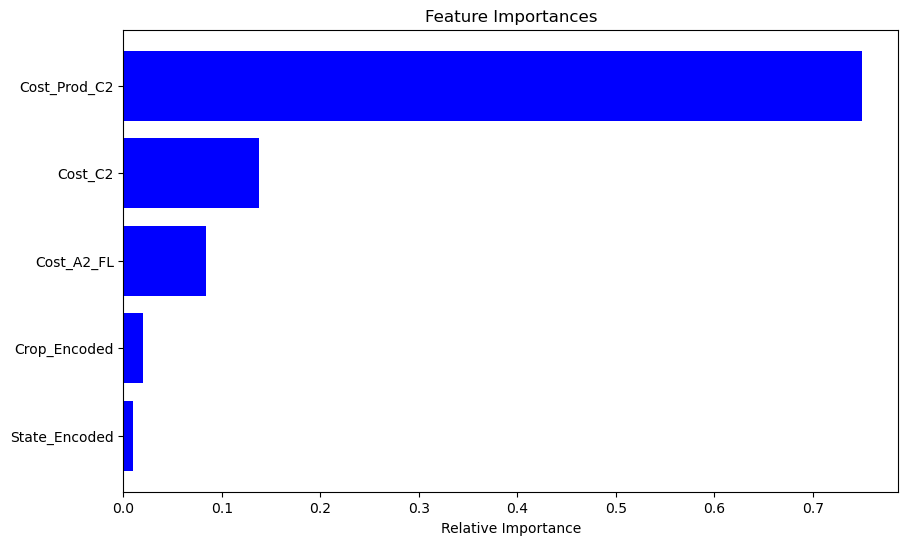

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the Random Forest model
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)

# Plotting
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Visualize Actual vs. Predicted

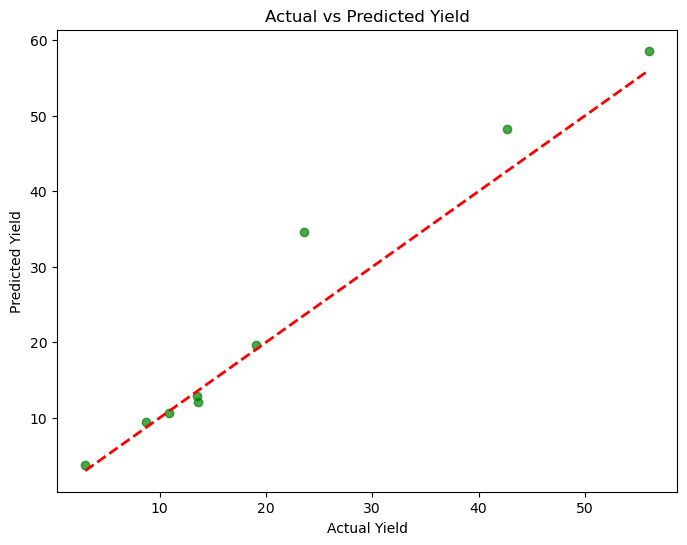

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Actual vs Predicted Yield')
plt.show()

### Making a Real Prediction

In [27]:
import pandas as pd

# Creating a DataFrame for the sample input to match training feature names
sample_df = pd.DataFrame([[20000, 30000, 1500, 0, 4]], 
                         columns=['Cost_A2_FL', 'Cost_C2', 'Cost_Prod_C2', 'Crop_Encoded', 'State_Encoded'])

prediction = model.predict(sample_df)
print(f"Predicted Crop Yield: {prediction[0]:.2f} Quintals/Hectare")

Predicted Crop Yield: 15.95 Quintals/Hectare


#### Feature Importance

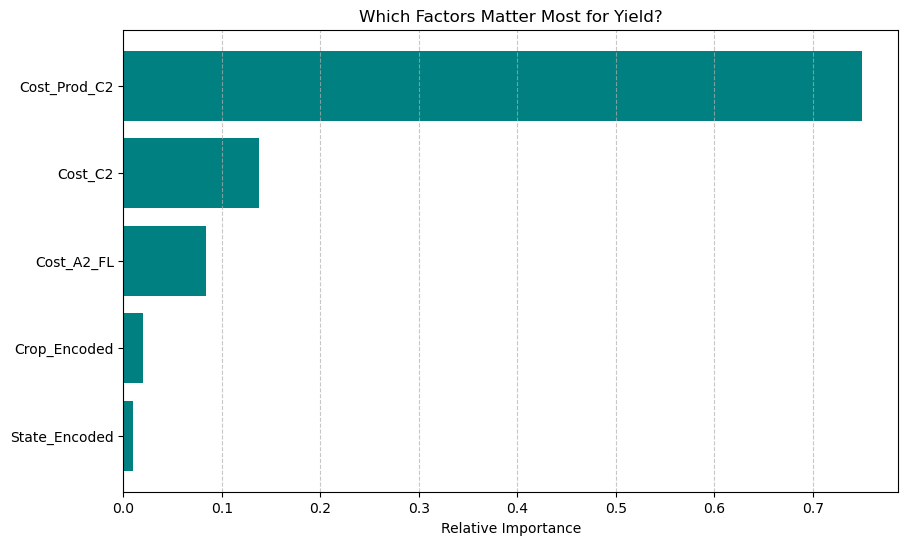

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Extracting feature importances
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Which Factors Matter Most for Yield?')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### Save the Model (Deployment Ready)

In [29]:
import joblib

# Saving the model and the label encoders
joblib.dump(model, 'crop_yield_model.pkl')
joblib.dump(le_crop, 'crop_encoder.pkl')
joblib.dump(le_state, 'state_encoder.pkl')

print("Model and Encoders saved successfully as .pkl files!")

Model and Encoders saved successfully as .pkl files!
